# Models: Bangkok PM2.5, 24 hours ahead

Input: `data/clean/hourly.csv` from `preprocess.ipynb`.

**Forecast setup:** at forecast time *t* we predict PM2.5 at *t*+24 h. Every input is known at or before *t*. Scored only where the station really measured PM2.5 at *t*+24 (imputed hours are never targets).

**Split:** tune on 2022 (train) and Jan to Jun 2023 (validation), retrain on 2022 to 2023, test on 2024. Split by target time.

Models: persistence, SARIMA, CAMS, LightGBM (with ablation and a leakage check). TFT runs in a separate Colab notebook on the same features and test rows.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
RAW, CLEAN, FIG = Path("data/raw"), Path("data/clean"), Path("figures")
TZ = "Asia/Bangkok"
H = 24
STATIONS = ["stou", "mineral", "highway"]
UNHEALTHY = 37.5  # Thai 24 h PM2.5 standard, µg/m³

hourly = pd.read_csv(CLEAN / "hourly.csv")
hourly["time"] = pd.to_datetime(hourly["time"], utc=True).dt.tz_convert(TZ)
print(hourly.shape)

(78912, 31)


## 1. Features at forecast time *t*

- PM2.5 at *t* and lags *t*-1 to *t*-168, rolling means ending at *t* (from the imputed series; imputation only used past and neighbour data)
- Weather for the target hour *t*+24 and the mean over *t*+1 to *t*+24, from archived forecasts
- Fire features at *t* (already restricted to detections before *t*)
- Calendar of the target hour; station as a category

In [2]:
WEATHER = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "precipitation", "wind_sin", "wind_cos"]
FIRE = [c for c in hourly.columns if c.startswith("fire_")]

def build_features(df, weather_cols=WEATHER):
    out = []
    for s, g in df.groupby("station", sort=False):
        g = g.set_index("time").sort_index()
        f = pd.DataFrame(index=g.index)
        f["station"] = s
        f["pm_t"] = g["pm25"]
        for k in [1, 2, 3, 6, 12, 24, 168]:
            f[f"pm_lag{k}"] = g["pm25"].shift(k)
        f["pm_mean6"] = g["pm25"].rolling(6, min_periods=3).mean()
        f["pm_mean24"] = g["pm25"].rolling(24, min_periods=12).mean()
        for c in weather_cols:
            f[f"wx_{c}_t24"] = g[c].shift(-H)
        f["wx_wind_mean_next24"] = g["wind_speed_10m"].rolling(H).mean().shift(-H)
        f["wx_rain_sum_next24"] = g["precipitation"].rolling(H).sum().shift(-H)
        for c in FIRE:
            f[c] = g[c]
        target_time = g.index + pd.Timedelta(hours=H)
        f["cal_hour_sin"] = np.sin(2 * np.pi * target_time.hour / 24)
        f["cal_hour_cos"] = np.cos(2 * np.pi * target_time.hour / 24)
        f["cal_dow"] = target_time.dayofweek
        f["cal_month_sin"] = np.sin(2 * np.pi * target_time.month / 12)
        f["cal_month_cos"] = np.cos(2 * np.pi * target_time.month / 12)
        f["cal_burning"] = target_time.month.isin([1, 2, 3, 4]).astype(int)
        f["target_time"] = target_time
        f["y"] = g["pm25_raw"].shift(-H)
        f["cams"] = g["cams_pm25"].shift(-H)
        out.append(f.reset_index(names="t"))
    X = pd.concat(out, ignore_index=True)
    X["station"] = X["station"].astype("category")
    return X

data = build_features(hourly)
data = data[data["y"].notna()].reset_index(drop=True)
print(f"{len(data):,} scorable rows (measured PM2.5 at t+24)")

67,475 scorable rows (measured PM2.5 at t+24)


In [3]:
FEATURES = {
    "PM2.5 only": [c for c in data.columns if c.startswith(("pm_", "cal_"))] + ["station"],
}
FEATURES["+ weather"] = FEATURES["PM2.5 only"] + [c for c in data.columns if c.startswith("wx_")]
# 2 fire features chosen on validation MAE (6.32 vs 7.16 with all 39, which overfit one training burning season)
FIRE_SELECTED = ["fire_upwind_48h", "fire_n_r100_300_72h"]
FEATURES["+ fire"] = FEATURES["+ weather"] + FIRE_SELECTED
FEATURES["+ fire (all 39, overfits)"] = FEATURES["+ weather"] + FIRE

year = data["target_time"].dt.year
month = data["target_time"].dt.month
train = data[year == 2022]
valid = data[(year == 2023) & (month <= 6)]
train_full = data[year == 2023].pipe(lambda d: pd.concat([train, d]))
test = data[year == 2024].copy()
print({k: len(v) for k, v in [("train", train), ("valid", valid), ("train 2022-23", train_full), ("test 2024", test)]})

{'train': 24314, 'valid': 9121, 'train 2022-23': 45682, 'test 2024': 21793}


## 2. Baselines
**Persistence:** PM2.5 at *t*+24 = PM2.5 at *t*. **CAMS:** the Copernicus model's value for *t*+24.

In [4]:
test["pred_persistence"] = test["pm_t"]
test["pred_cams"] = test["cams"]

**SARIMA(2,0,1)(1,0,1)₂₄**, one per station, fit once on 2022 to 2023. Refitting at each of the 8,784 test origins would be too slow, so the fitted model is run through 2024 with a Kalman filter (no refit). The 24-step forecast from each origin is Z·T²⁴·aₜ, where aₜ is the filtered state at *t*; this matches statsmodels' own `forecast(24)` exactly and takes seconds.

In [5]:
sarima_pred = []
for s in STATIONS:
    g = hourly[hourly.station == s].set_index("time").sort_index()["pm25"]
    mu = g[:"2023-12-31"].mean()
    y = (g - mu).to_numpy()
    n_train = int((g.index <= "2023-12-31 23:00").sum())
    fit = SARIMAX(y[:n_train], order=(2, 0, 1), seasonal_order=(1, 0, 1, 24)).fit(disp=False, maxiter=50)
    model = SARIMAX(y, order=(2, 0, 1), seasonal_order=(1, 0, 1, 24))
    state = model.filter(fit.params).filter_results.filtered_state
    T, Z = (np.squeeze(model.ssm[k], axis=2) if model.ssm[k].ndim == 3 else model.ssm[k] for k in ("transition", "design"))
    f24 = (Z @ np.linalg.matrix_power(T, H) @ state).ravel() + mu
    sarima_pred.append(pd.DataFrame({"station": s, "t": g.index, "pred_sarima": f24}))
    print(s, "fitted")

sarima_pred = pd.concat(sarima_pred).astype({"station": data["station"].dtype})
test = test.merge(sarima_pred, on=["station", "t"], how="left")

stou fitted


mineral fitted


highway fitted


## 3. LightGBM with ablation
Same model, growing feature sets. The gain at each step is what that data source adds. The fire set is the 2 features that scored best on validation; all 39 fire features are kept as a row to show the overfitting. Early stopping on the Jan to Jun 2023 validation set, then retrain on 2022 to 2023 with the chosen number of trees.

In [6]:
PARAMS = dict(objective="regression", learning_rate=0.03, num_leaves=63, min_data_in_leaf=50,
              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, verbose=-1, seed=42)

def fit_lgb(cols, tr, va, tr_full):
    dtrain = lgb.Dataset(tr[cols], tr["y"])
    booster = lgb.train(PARAMS, dtrain, 3000,
                        valid_sets=[lgb.Dataset(va[cols], va["y"], reference=dtrain)],
                        callbacks=[lgb.early_stopping(100, verbose=False)])
    return lgb.train(PARAMS, lgb.Dataset(tr_full[cols], tr_full["y"]), booster.best_iteration)

models = {}
for name, cols in FEATURES.items():
    models[name] = fit_lgb(cols, train, valid, train_full)
    test[f"pred_lgb {name}"] = models[name].predict(test[cols])
    print(f"{name}: {models[name].num_trees()} trees")

PM2.5 only: 122 trees


+ weather: 124 trees


+ fire: 114 trees


+ fire (all 39, overfits): 63 trees


### Leakage check: observed instead of forecast weather

Rerun the full model with weather that was *observed* at *t*+24. It looks better, but that weather is not known at forecast time. The gap is the leakage we avoided by using archived forecasts.

In [7]:
obs = []
for s in STATIONS:
    w = pd.read_csv(RAW / "weather_observed" / f"{s}.csv")
    w["time"] = pd.to_datetime(w.pop("datetime_utc"), utc=True).dt.tz_convert(TZ)
    rad = np.radians(w.pop("wind_direction_10m"))
    w["wind_sin"], w["wind_cos"] = np.sin(rad), np.cos(rad)
    w["station"] = s
    obs.append(w)
obs = pd.concat(obs)
hourly_obs = hourly.drop(columns=WEATHER).merge(obs[["station", "time", *WEATHER]], on=["station", "time"], how="left")

data_obs = build_features(hourly_obs)
data_obs = data_obs[data_obs["y"].notna()]
yo = data_obs["target_time"].dt.year
mo = data_obs["target_time"].dt.month
leak_model = fit_lgb(FEATURES["+ fire"], data_obs[yo == 2022], data_obs[(yo == 2023) & (mo <= 6)], data_obs[yo.isin([2022, 2023])])
leak = data_obs[yo == 2024][["station", "t"]].assign(**{"pred_lgb observed weather (leaky)": leak_model.predict(data_obs[yo == 2024][FEATURES["+ fire"]])})
test = test.merge(leak, on=["station", "t"], how="left")

## 4. Evaluation on 2024
All models are scored on the same rows: hours where every model has a prediction.

In [8]:
PRED = [c for c in test.columns if c.startswith("pred_")]
scored = test.dropna(subset=PRED).copy()
print(f"{len(scored):,} of {len(test):,} test rows scored by every model")

def metrics(df):
    rows = {}
    for p in PRED:
        err = df[p] - df["y"]
        rows[p.removeprefix("pred_")] = {"MAE": err.abs().mean(), "RMSE": np.sqrt((err ** 2).mean())}
    return pd.DataFrame(rows).T

burning = scored["target_time"].dt.month <= 4
results = pd.concat({"all 2024": metrics(scored), "burning season (Jan-Apr)": metrics(scored[burning]),
                     "rest of year": metrics(scored[~burning])}, axis=1).round(2)
results.sort_values(("all 2024", "MAE"))

21,511 of 21,793 test rows scored by every model


all 2024        burning season (Jan-Apr)         \
                                   MAE   RMSE                      MAE   RMSE   
lgb + fire                        5.01   7.27                     6.45   9.18   
lgb observed weather (leaky)      5.03   7.32                     6.51   9.27   
lgb + weather                     5.22   7.61                     6.75   9.65   
lgb + fire (all 39, overfits)     5.46   8.08                     7.19  10.53   
sarima                            5.67   8.12                     7.43  10.27   
lgb PM2.5 only                    5.67   8.47                     7.72  11.07   
persistence                       5.89   8.66                     7.60  10.96   
cams                             12.93  20.83                    14.59  22.22   

                              rest of year         
                                       MAE   RMSE  
lgb + fire                            4.11   5.78  
lgb observed weather (leaky)          4.11   5.78  
lgb + weather                         4.26   6.00  
lgb + fire (all 39, overfits)         4.37   6.07  
sarima                                4.58   6.42  
lgb PM2.5 only                        4.40   6.33  
persistence                           4.82   6.86  
cams                                 11.90  19.91

In [9]:
per_station = scored.groupby("station", observed=True).apply(lambda d: metrics(d)["MAE"]).T.round(2)
per_station

station,highway,mineral,stou
MAE,,,
persistence,6.42,4.87,6.37
cams,13.86,11.86,13.08
sarima,6.15,4.66,6.19
lgb PM2.5 only,6.02,4.51,6.48
lgb + weather,5.52,4.32,5.80
lgb + fire,5.28,4.19,5.55
"lgb + fire (all 39, overfits)",5.88,4.40,6.08
lgb observed weather (leaky),5.26,4.21,5.62


### Unhealthy-day detection

For each model, a day's forecast is the mean of its 24 hourly *t*+24 predictions for that day. The last of those is made at 23:00 the day before, so it is a next-day forecast issued at 23:00. A day is unhealthy if the mean is above 37.5 µg/m³. Only days with at least 18 measured hours are scored. Persistence here means "tomorrow looks like today".

In [10]:
scored["date"] = scored["target_time"].dt.date
daily = scored.groupby(["station", "date"], observed=True).agg(n=("y", "size"), y=("y", "mean"), **{p: (p, "mean") for p in PRED})
daily = daily[daily["n"] >= 18]
actual = daily["y"] > UNHEALTHY

def f1_row(pred):
    hit = pred > UNHEALTHY
    tp = (hit & actual).sum()
    precision = tp / max(hit.sum(), 1)
    recall = tp / max(actual.sum(), 1)
    return {"precision": precision, "recall": recall, "F1": 2 * precision * recall / max(precision + recall, 1e-9)}

print(f"{len(daily)} station-days scored, {actual.sum()} unhealthy")
pd.DataFrame({p.removeprefix("pred_"): f1_row(daily[p]) for p in PRED}).T.round(2)

803 station-days scored, 116 unhealthy


,precision,recall,F1
persistence,0.74,0.74,0.74
cams,0.47,0.59,0.53
sarima,0.82,0.66,0.73
lgb PM2.5 only,0.79,0.55,0.65
lgb + weather,0.89,0.61,0.72
lgb + fire,0.87,0.68,0.76
"lgb + fire (all 39, overfits)",0.94,0.50,0.65
lgb observed weather (leaky),0.86,0.66,0.75


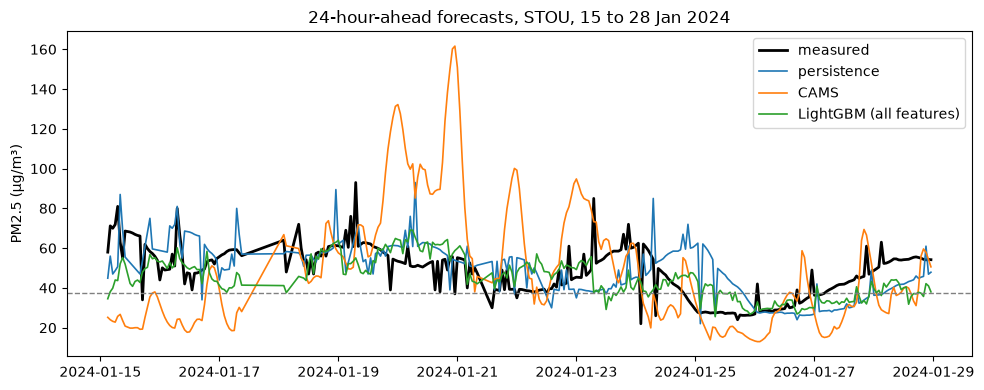

In [11]:
week = scored[(scored.station == "stou") & (scored.target_time >= "2024-01-15") & (scored.target_time < "2024-01-29")]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(week.target_time, week.y, color="black", lw=2, label="measured")
for p, lbl in [("pred_persistence", "persistence"), ("pred_cams", "CAMS"), ("pred_lgb + fire", "LightGBM (all features)")]:
    ax.plot(week.target_time, week[p], lw=1.2, label=lbl)
ax.axhline(UNHEALTHY, ls="--", color="grey", lw=1)
ax.set(ylabel="PM2.5 (µg/m³)", title="24-hour-ahead forecasts, STOU, 15 to 28 Jan 2024")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "forecast_example.png", dpi=150)
plt.show()

## 5. What drives the forecast
SHAP values from LightGBM (`pred_contrib`), summed by data source. Does fire matter more in the burning season?

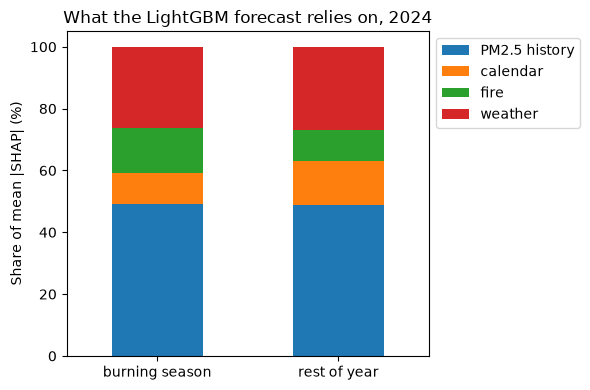

,burning season,rest of year
PM2.5 history,49.0,48.7
calendar,10.2,14.4
fire,14.6,10.1
weather,26.2,26.8


In [12]:
m = models["+ fire"]
cols = FEATURES["+ fire"]
contrib = pd.DataFrame(m.predict(scored[cols], pred_contrib=True)[:, :-1], columns=cols).abs()
source = {c: ("fire" if c.startswith("fire_") else "weather" if c.startswith("wx_") else
              "calendar" if c.startswith("cal_") or c == "station" else "PM2.5 history") for c in cols}
by_source = contrib.T.groupby(source).sum().T
share = pd.DataFrame({"burning season": by_source[burning.to_numpy()].mean(), "rest of year": by_source[~burning.to_numpy()].mean()})
share = (share / share.sum() * 100).round(1)
ax = share.T.plot.bar(stacked=True, figsize=(6, 4), rot=0)
ax.set(ylabel="Share of mean |SHAP| (%)", title="What the LightGBM forecast relies on, 2024")
ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(FIG / "shap_by_source.png", dpi=150)
plt.show()
share

In [13]:
test[["station", "t", "target_time", "y", *PRED]].to_csv(CLEAN / "test_predictions.csv", index=False)
data.to_csv(CLEAN / "features.csv", index=False)  # same features and rows for the TFT notebook
print("saved test_predictions.csv and features.csv")

saved test_predictions.csv and features.csv
